In [1]:
# Step - Length in the Limit: Analitical Results (?)
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

l0_per = 1
l0_par = 2

l_per = l0_per*2
l_par = l0_par*3

beta = 2

mu = 1

Expression from Gouws Thesis:

$$
f = \frac{\mu}{2}\left\{ \frac{2\ell^\perp_0}{\ell^\perp}\alpha^{2/3}\beta^{2/3} + \frac{\ell^{||}_0}{\ell^{||}}\alpha^{-4/3}\beta^{2/3} + \ln\left[ \frac{(\ell^\perp)^2\ell^{||}}{\ell_0^\perp)^2\ell_0^{||}} \right] \right\}
$$

Given the nematic limit.

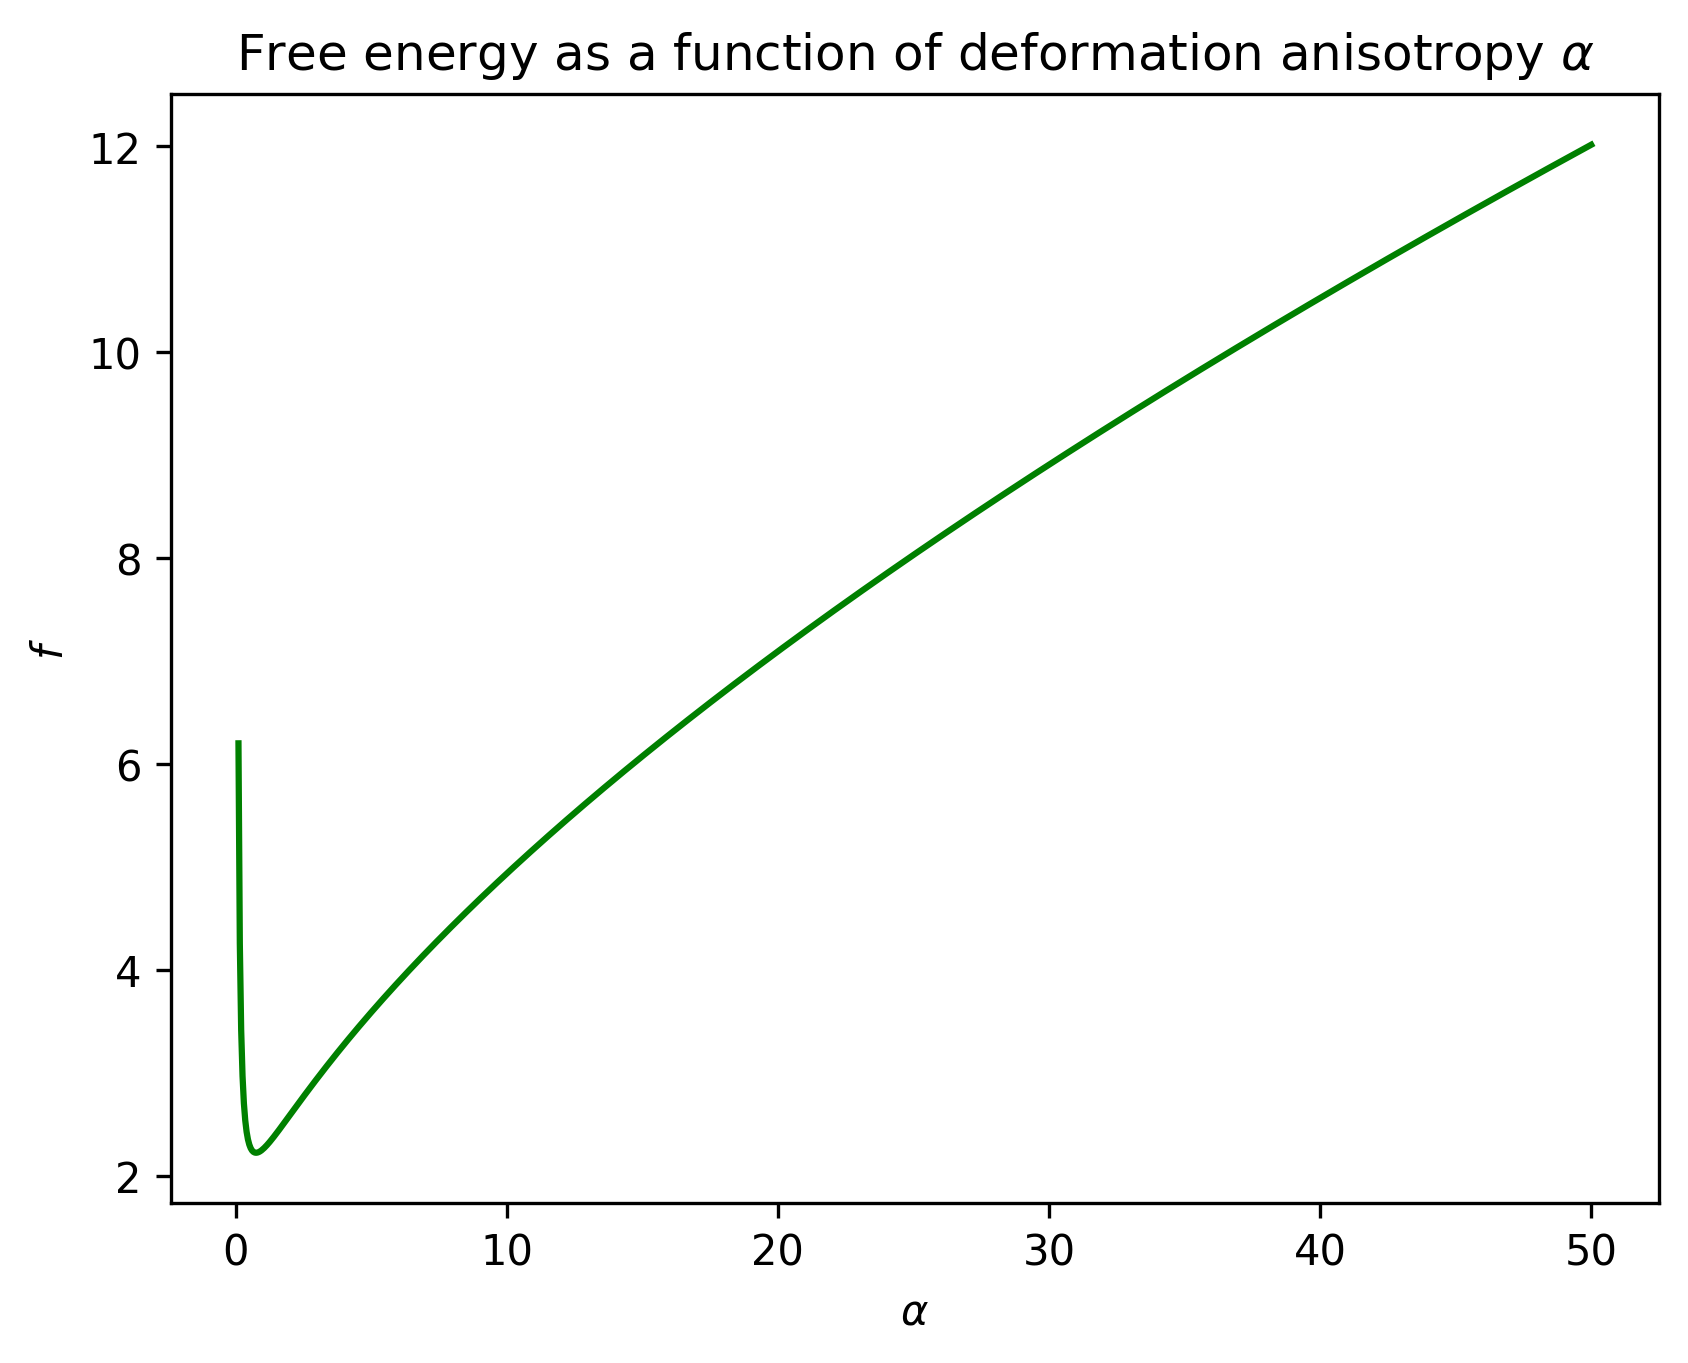

In [2]:
n = 1000
alphas = np.linspace(0.1, 50, n)

f = (mu/2)*((2*l0_per*alphas**(2/3)*beta**(2/3))/l_per + (l0_par*alphas**(-4/3)*beta*(2/3))/l_par + np.log((l_per**2*l_par)/(l0_per**2*l0_par)))

plt.figure(dpi=300)
plt.plot(alphas,f,color="g")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$f$")
plt.title("Free energy as a function of deformation anisotropy " + r"$\alpha$")
plt.show()

Define the following expresion using symbolic library used by gous, SymPy:

$$
\textbf{L} = \ell^\perp\textbf{I}+(\ell^{||}-\ell^\perp)\hat{\textbf{n}}\otimes\hat{\textbf{n}}
$$

In the nematic limit, that is $\psi=0 \rightarrow \hat{\textbf{n}}_0=\hat{\textbf{n}}=\hat{\textbf{e}}_z$.

Important note, the initial and final directional vector stays the same, so in this case the change is just of the step-length scales, $\ell$, which also facilitates calculations.

In [22]:
# Tensor product of the nematic limit psi=0 -> definition of the step-lenght tensor L
dim = 3

z = np.array([0,0,1.0])

Id = sp.Matrix(np.identity(dim))

l_per, l_par = sp.symbols('ell_perp ell_par')

expr = l_per*Id + (l_par - l_per)*sp.Matrix(np.kron(z,z).reshape(dim, dim))
sp.latex(expr)
expr

Matrix([
[1.0*ell_perp,            0,           0],
[           0, 1.0*ell_perp,           0],
[           0,            0, 1.0*ell_par]])

So what this matrix tells us is the different lenghts throught the different directions of the object, in this case we have in $zz$, the face in $z$ pointing $z$ the lenght of the parallel step-lenght, $\ell^{||}$, which is consistent with the logic that the our parallel component is indeed the $\hat{\textbf{z}}$ axis.

In [18]:
# Making a generalized step-length vector: simbolic

# Simbolic
xs,ys,zs,psi0,psi = sp.symbols('x y z psi_0 psi')

phi = sp.Matrix([-sp.sin(xs), sp.cos(ys), 0])
z = sp.Matrix([0,0,zs])

n0 = -sp.sin(psi0)*phi + sp.cos(psi0)*z

# Evaluate expresion in an arbitrary position
n0.evalf(subs={xs:1, ys:1, zs:1, psi0:np.deg2rad(40)})

Matrix([
[ 0.540887122945246],
[-0.347299627697107],
[ 0.766044443118978]])